In [5]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
# KNeighborsRegressor : 선택된 k개 이웃의 타깃(target) 값들을 평균 내어 최종 예측값으로 사용
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings(action='ignore')

In [7]:
from sklearn.datasets import fetch_openml

boston = fetch_openml(name='Boston', version=1,as_frame=True)

In [9]:
boston.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [10]:
print(boston.DESCR)

**Author**:   
**Source**: Unknown - Date unknown  
**Please cite**:   

The Boston house-price data of Harrison, D. and Rubinfeld, D.L. 'Hedonic
prices and the demand for clean air', J. Environ. Economics & Management,
vol.5, 81-102, 1978.   Used in Belsley, Kuh & Welsch, 'Regression diagnostics
...', Wiley, 1980.   N.B. Various transformations are used in the table on
pages 244-261 of the latter.
Variables in order:
CRIM     per capita crime rate by town
ZN       proportion of residential land zoned for lots over 25,000 sq.ft.
INDUS    proportion of non-retail business acres per town
CHAS     Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)
NOX      nitric oxides concentration (parts per 10 million)
RM       average number of rooms per dwelling
AGE      proportion of owner-occupied units built prior to 1940
DIS      weighted distances to five Boston employment centres
RAD      index of accessibility to radial highways
TAX      full-value property-tax rate per $10

In [11]:
boston.url

'https://www.openml.org/d/531'

In [15]:
X = boston.data # 독립변수
y = boston.target # 종속변수

X_train, X_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=42)

In [16]:
X.head(2)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.9,4.98
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.9,9.14


In [18]:
y

0      24.0
1      21.6
2      34.7
3      33.4
4      36.2
       ... 
501    22.4
502    20.6
503    23.9
504    22.0
505    11.9
Name: MEDV, Length: 506, dtype: float64

In [19]:
X_train.shape, X_test.shape

((404, 13), (102, 13))

In [20]:
k = 3
knn_regressor = KNeighborsRegressor(n_neighbors=k)
knn_regressor.fit(X_train, y_train)
y_pred = knn_regressor.predict(X_test)

In [21]:
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R-squared:",r2_score(y_test, y_pred))

Mean Squared Error: 21.65955337690632
R-squared: 0.7046442656646525


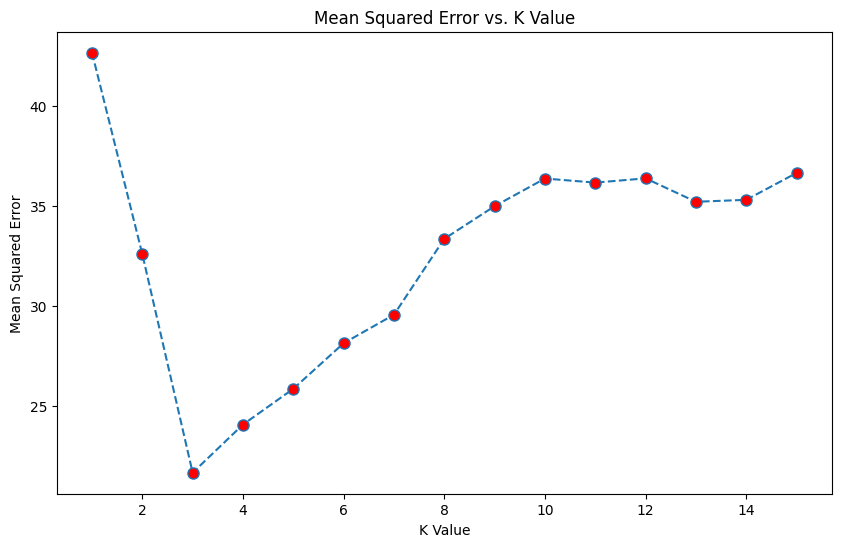

In [26]:
mse_values = []
for i in range(1,16):
    knn_i = KNeighborsRegressor(n_neighbors=i)
    knn_i.fit(X_train, y_train)
    y_pred_i = knn_i.predict(X_test)
    mse_values.append(mean_squared_error(y_test, y_pred_i))

plt.figure(figsize=(10,6))
plt.plot(range(1,16), mse_values, marker='o', linestyle='dashed', markersize=8, markerfacecolor='red')
plt.title("Mean Squared Error vs. K Value")
plt.xlabel("K Value")
plt.ylabel("Mean Squared Error")
plt.show()